# 01 Data Setup and Embeddings
500 reviewed human proteins are fetched from UniProt, ESM2 embeddings are computed, the embedding space is explored through EDA, and nearest neighbour search is implemented across three distance metrics.

## Data Fetching and Embedding Computation
The UniProt REST API is queried for reviewed human proteins (organism: Homo sapiens) with GO terms, protein family, and sequence. Each sequence is passed through ESM2 to produce a 320-dimensional embedding vector.

In [ ]:
import pathlib, sys, os

project_root = pathlib.Path.cwd()
for _ in range(5):
    if (project_root / "environment.yml").exists():
        break
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.data_loader import fetch_uniprot, compute_embeddings, save_data, load_data
import esm

df = fetch_uniprot(500)
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
model.eval()
embeddings = compute_embeddings(df, model, alphabet)
save_data(df, embeddings)
print(embeddings.shape)

## Loading Saved Data

In [3]:
df2, emb2 = load_data()
print(df2.shape)    
print(emb2.shape)   

(500, 5)
(500, 320)


## Exploratory Data Analysis

In [9]:
print("Missing GO terms:", df2["go_terms"].isna().sum())
print("Missing sequences:", df2["sequence"].isna().sum())
print("Missing family labels:", df2["family"].isna().sum())

print("\nUnique families:", df2["family"].nunique())
print("\nTop 10 families:\n", df2["family"].value_counts().head(10))
print("\nSequence length stats:\n", df2['sequence'].str.len().describe())

Missing GO terms: 1
Missing sequences: 0
Missing family labels: 117

Unique families: 340

Top 10 families:
 family
G-protein coupled receptor 1 family                              7
Heparin-binding growth factors family                            5
Intermediate filament family                                     4
Tetraspanin (TM4SF) family                                       3
Krueppel C2H2-type zinc-finger protein family                    3
Peptidase M10A family                                            3
Histone H2A family                                               3
Concentrative nucleoside transporter (CNT) (TC 2.A.41) family    2
Ubiquitin-conjugating enzyme family                              2
CDK2AP family                                                    2
Name: count, dtype: int64

Sequence length stats:
 count     500.000000
mean      572.866000
std       530.087795
min        16.000000
25%       246.500000
50%       434.500000
75%       671.000000
max      4834.00

In [10]:
df_labeled = df2[df2["family"].notna()].reset_index(drop=True)
emb_labeled = emb2[df2["family"].notna()]
print(f"Proteins with family labels: {len(df_labeled)}")

Proteins with family labels: 383


### Embedding Quality Check
The distribution of L2 norms is inspected across all embeddings. A tight distribution indicates cosine and Euclidean distances will behave similarly.

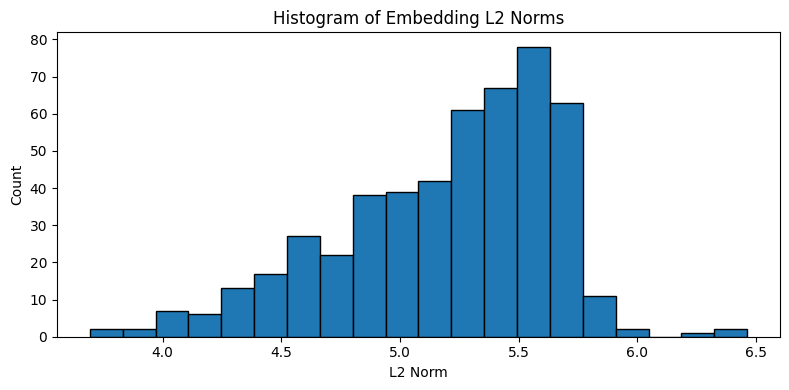

In [11]:
import numpy as np
import matplotlib.pyplot as plt

l2_norms = np.linalg.norm(emb2, axis=1)

plt.figure(figsize=(8, 4))
plt.hist(l2_norms, bins=20, edgecolor='black')
plt.xlabel('L2 Norm')
plt.ylabel('Count')
plt.title('Histogram of Embedding L2 Norms')
plt.tight_layout()
plt.show()

## Nearest neighbours

In [7]:
print(df2[df2["uniprot_id"] == "P01308"])

    uniprot_id                                       protein_name  \
391     P01308  Insulin [Cleaved into: Insulin B chain; Insuli...   

                                              sequence  \
391  MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGER...   

                                              go_terms          family  
391  endoplasmic reticulum lumen [GO:0005788]; endo...  Insulin family  


In [8]:
from src.search import nearest_neighbours

insulin_idx = df2[df2["uniprot_id"] == "P01308"].index[0]
insulin_emb = emb2[insulin_idx]

print("Cosine")
print(nearest_neighbours(insulin_emb, emb2, df2, metric="cosine", n=5))

print("Euclidean")
print(nearest_neighbours(insulin_emb, emb2, df2, metric="euclidean", n=5))

print("Manhattan")
print(nearest_neighbours(insulin_emb, emb2, df2, metric="manhattan", n=5))

Cosine
(                                          protein_name  \
488                                           Secretin   
273  Left-right determination factor 1 (Left-right ...   
456  Gastrin-releasing peptide (GRP) [Cleaved into:...   
457               Acetylcholine receptor subunit gamma   
361               Fibroblast growth factor 19 (FGF-19)   

                                                family  
488                                    Glucagon family  
273                                    TGF-beta family  
456            Bombesin/neuromedin-B/ranatensin family  
457  Ligand-gated ion channel (TC 1.A.9) family, Ac...  
361              Heparin-binding growth factors family  , array([488, 273, 456, 457, 361]))
Euclidean
(                                          protein_name  \
488                                           Secretin   
273  Left-right determination factor 1 (Left-right ...   
456  Gastrin-releasing peptide (GRP) [Cleaved into:...   
457               Acety

## Summary
- 500 reviewed human proteins fetched with 340 unique protein families
- 117 proteins missing family labels — retained for unsupervised analysis
- L2 norms tightly distributed (~4.5–6.0), making cosine and Euclidean distances broadly equivalent
- All three distance metrics (cosine, Euclidean, Manhattan) return identical top-5 neighbours for insulin, suggesting the embedding geometry is robust to metric choice